# Baseline search algorithm

In [1]:
import os
import random
import torch
import json
from ultralytics import YOLO 
from scipy.spatial.transform import Rotation as R
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import yolo_patch_sigmoid
import io
import contextlib
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils
from habitat_sim.utils import viz_utils as vut
from habitat_sim.utils.common import quat_from_angle_axis, quat_to_angle_axis
from habitat_sim.utils.common import d3_40_colors_rgb

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

In [2]:
# Robotic agent properties
AGENT_RADIUS = 0.15 # 15 cm
AGENT_HEIGHT = 1.0 # 100 cm

# Sensor observations scale
OBS_SCALE = 9/16 # WIDTH/HEIGHT

# Maps sizes
CELL_SIDE = 2*AGENT_RADIUS # 30 cm
MAP_RESOLUTION = 0.01 # 1 cm

# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration (index selects the simulation)
simulation = simulations[2]

# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera_intrinsics.json', 'r') as f:
    cam_intrcs = json.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

Renderer: NVIDIA GeForce GTX 1060 6GB/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 535.230.02
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


[11:35:30:068505]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'ai2thor-hab' : Lighting Layout Attributes '/home/joaocbranco/projects/habitat-meta/ai2thor-hab/ai2thor-hab/configs/scenes/RoboTHOR/FloorPlan_Train3_4.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its binding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
[11:35:30:316875]:[Warning]:[Sim] Simulator.cpp(595)::instanceStageForSceneAttributes : The active scene does not contain semantic annotations : activeSemanticSceneID_ = 0
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 2 pixels
Trade::BasisImporter::image2D(): Y-flippin

In [3]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = habitat_sim.NavMeshSettings()
navmesh_settings.agent_height = AGENT_HEIGHT
navmesh_settings.agent_radius = AGENT_RADIUS
navmesh_settings.agent_max_climb = 0.2
navmesh_settings.agent_max_slope = 45.0
navmesh_settings.include_static_objects = True  # Include static objects in the navmesh computation

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map = myutils.map_to_rgb(topdown_map)
topdown_map = myutils.add_axis_to_map(topdown_map)
topdown_resolution = topdown_map.shape[:2]

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
occ_grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
occ_grid_map = myutils.map_to_rgb(occ_grid_map)
occ_grid_resolution = occ_grid_map.shape[:2]

# Occupiable positions
grid_occ_positions = []
real_wrld_positions = []
map_occ_positions = []
for x_g in range(occ_grid_resolution[0]):   
    for y_g in range(occ_grid_resolution[1]):
        if occ_grid_map[x_g, y_g, 0] == 255: # White pixel
            # Convert to real world position and map position
            real_wrld_z, real_wrld_x = maps.from_grid(x_g, y_g, occ_grid_resolution, pathfinder=sim.pathfinder)
            map_x, map_y = maps.to_grid(real_wrld_z, real_wrld_x, topdown_resolution, pathfinder=sim.pathfinder)

            # Check if the position is navigable and not occupied by an object
            if sim.pathfinder.is_navigable([real_wrld_x, 0.0, real_wrld_z]) and topdown_map[map_x, map_y, 0] == 255: # White pixel
                real_wrld_positions.append([real_wrld_x, 0.0, real_wrld_z])
                map_occ_positions.append([map_x, map_y])
                grid_occ_positions.append([x_g, y_g]) # Add grid position
            else:
                occ_grid_map[x_g, y_g, :] = [128, 128, 128] # Grey pixel

# Count the number of occupiable positions
num_cells = len(grid_occ_positions)

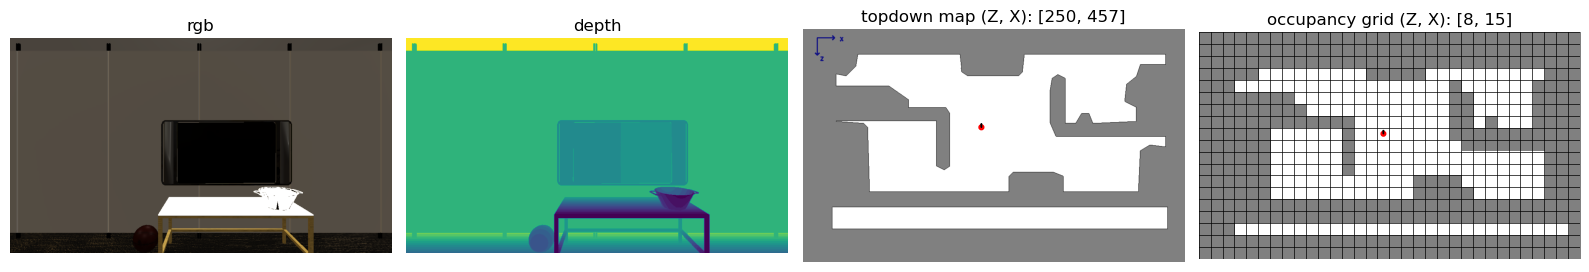

In [4]:
# Initialize an agent
agent = sim.initialize_agent(sim_settings["default_agent"])

# Sample a random position (within the possible ones)
grid_position = random.choice(grid_occ_positions)
idx = grid_occ_positions.index(grid_position)
wrld_position = real_wrld_positions[idx]
map_position = map_occ_positions[idx]

# Sample a random yaw rotation
agent_yaw = random.choice([0, 90, 180, 270])
agent_quart = myutils.yaw_to_quaternion(agent_yaw)

# Set agent state
agent_state = habitat_sim.AgentState()
agent_state.position = wrld_position
agent_state.rotation = agent_quart
agent.set_state(agent_state)

# Compute agent radius in both maps
min_bounds, max_bounds = sim.pathfinder.get_bounds()
x_dim = max_bounds[0] - min_bounds[0]
topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
occ_grid_radius = (AGENT_RADIUS / x_dim * occ_grid_resolution[0])

# Get initial agent position tuple and radius tuple
agent_radius_tpl = (topdown_radius, occ_grid_radius)
agent_positions_tpl = (map_position, grid_position)

# Get initial observations and maps
observations = sim.get_sensor_observations(0)
rgb = observations["color_sensor"]
depth = observations["depth_sensor"]

# Display the initial simulation state (maps + observations)
simtools.display_sim_state(rgb, depth, topdown_map, occ_grid_map, agent_positions_tpl, agent_radius_tpl, agent_yaw)

In [5]:
# Define possible actions
actions = {
    "move_forward",
    "move_backward",
    "move_left",
    "move_right",
    "turn_around",
    "turn_left",
    "turn_right",
}

# Standard thresholds
MAX_ITER = 500
CONFIDENCE_THRESHOLD = 0.75

# Simulation parameters
INIT_NUM_CLUSTER = 4
MAX_NUM_CLUSTER = num_cells
num_clusters = INIT_NUM_CLUSTER

# Visualization parameters
DISPLAY_STEP = 1

# Metrics
OBJECT_FOUND = False
num_actions = 0
travelled_distance = 0.0
closeness = float("inf")

-------------------------------
Number of clusters: 4


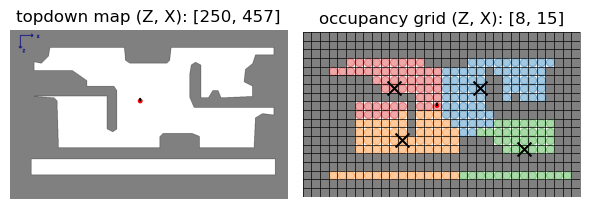

-------------------------------
NEXT CLUSTER: [6, 20]
PATH: [[7, 15], [6, 15], [6, 16], [6, 17], [6, 18], [6, 19], [6, 20]]
Action:  turn_right


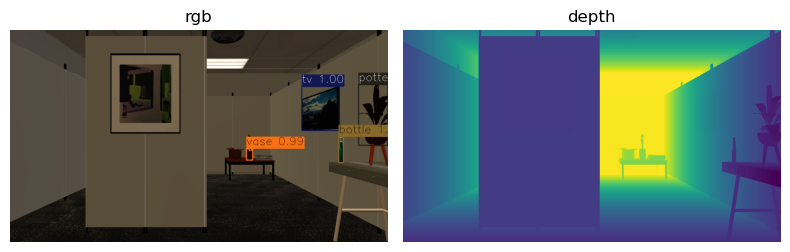

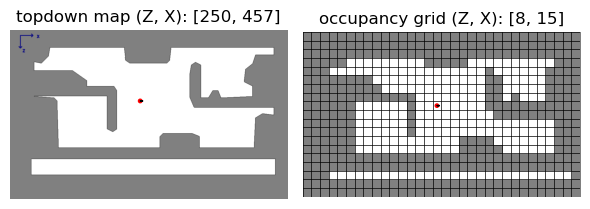

Action:  move_left


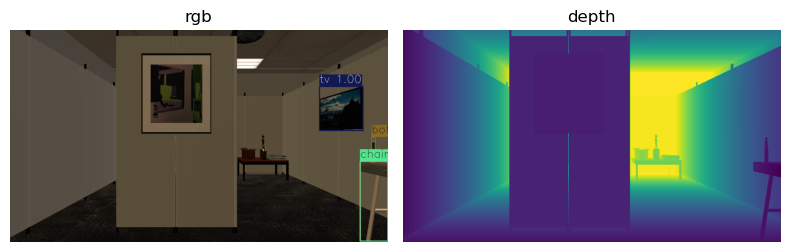

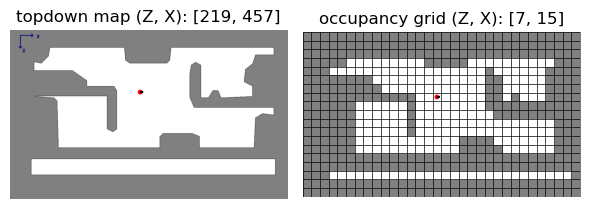

Action:  move_left


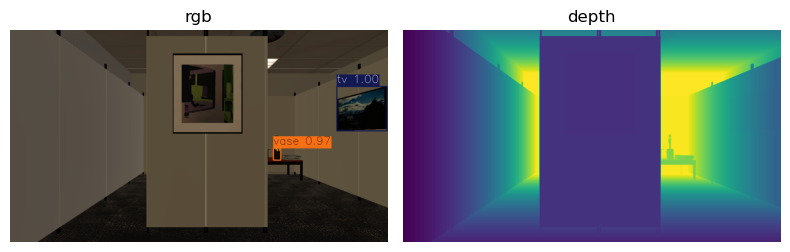

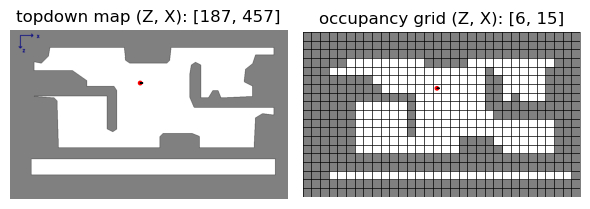

Action:  move_forward


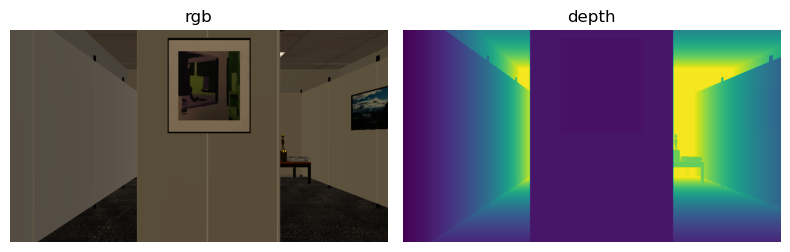

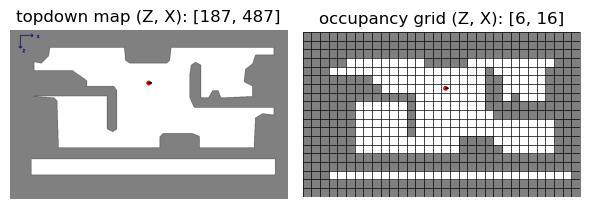

Action:  move_forward


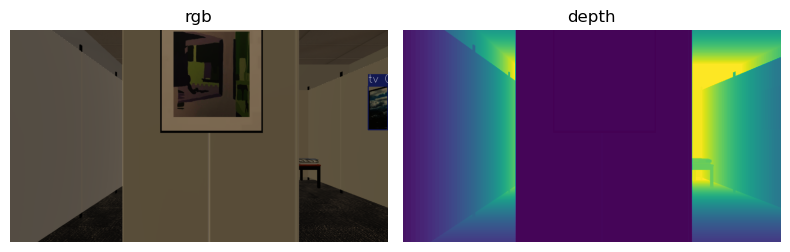

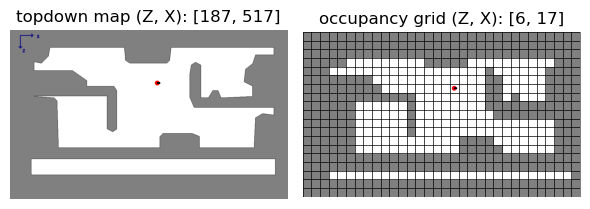

Action:  move_forward


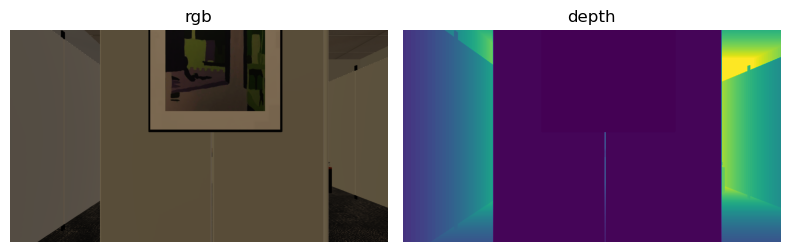

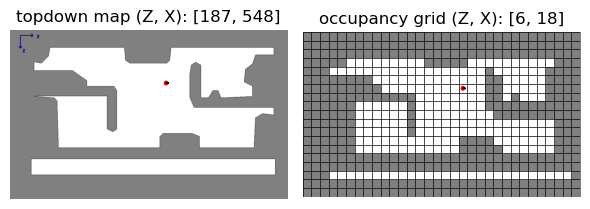

Action:  move_forward


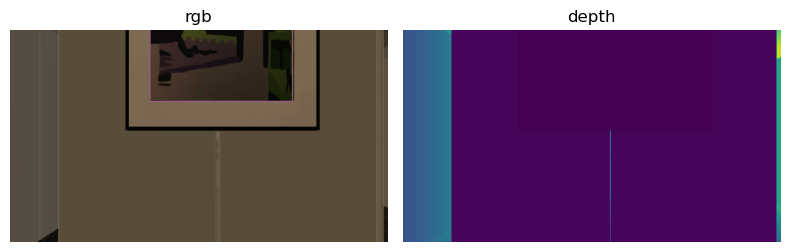

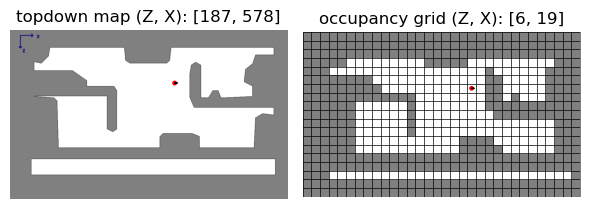

Action:  move_forward


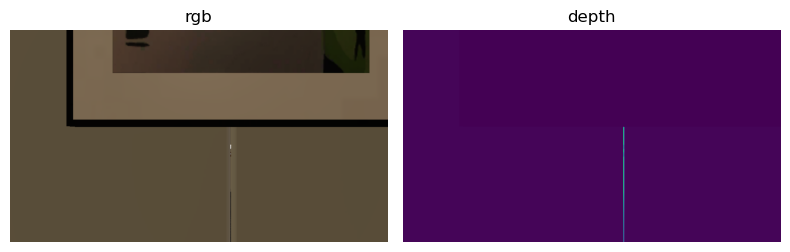

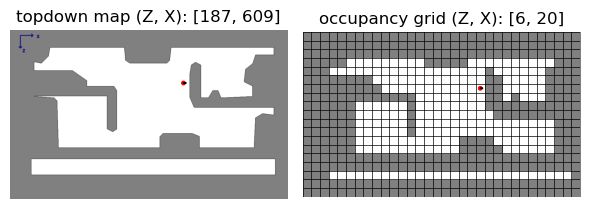

Taking observations at cluster center: [6, 20]
Action:  turn_right


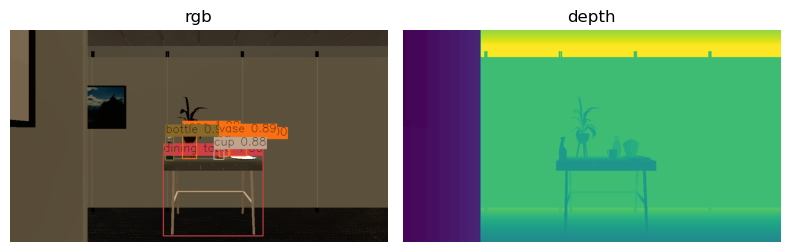

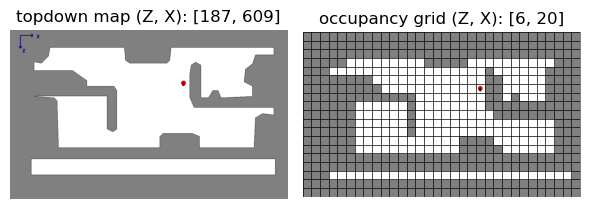

Action:  turn_right


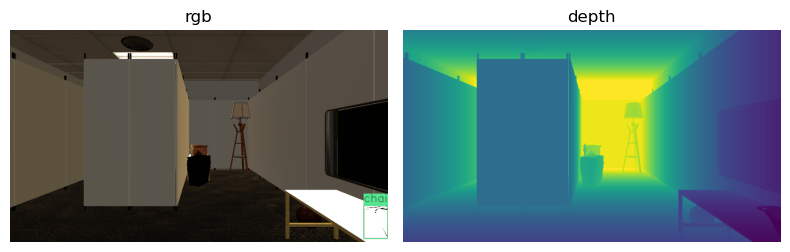

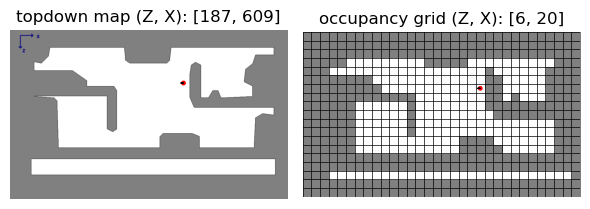

Action:  turn_right


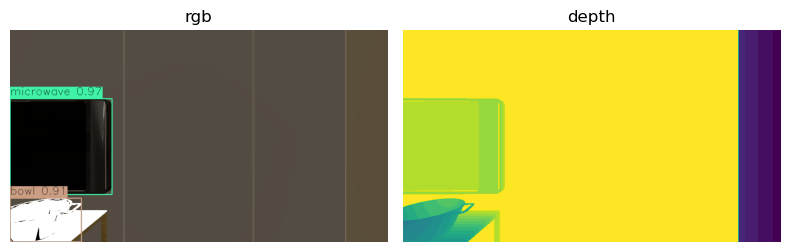

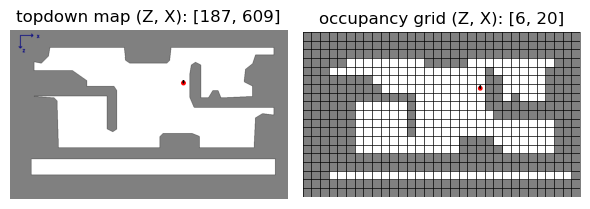

NEXT CLUSTER: [6, 10]
PATH: [[6, 19], [6, 18], [6, 17], [6, 16], [6, 15], [6, 14], [6, 13], [6, 12], [6, 11], [6, 10]]
Action:  turn_left


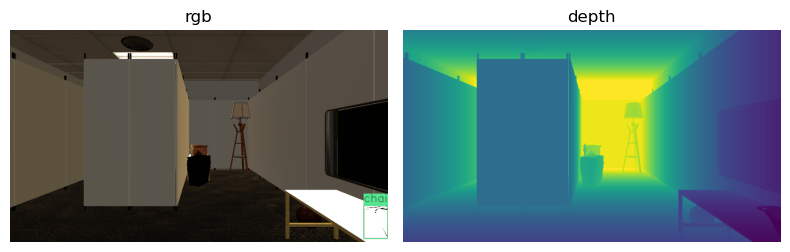

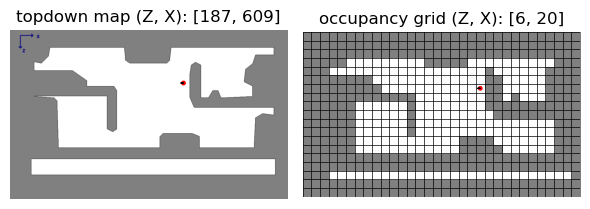

Action:  move_forward


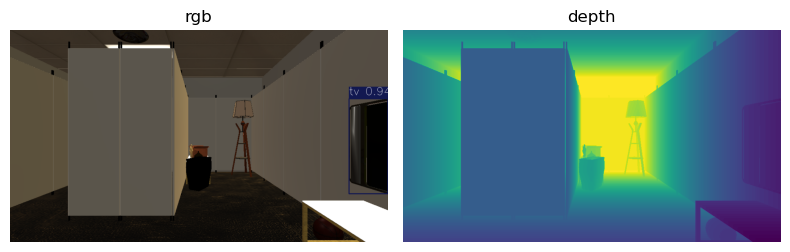

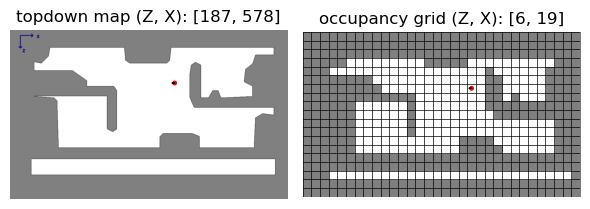

Action:  move_forward


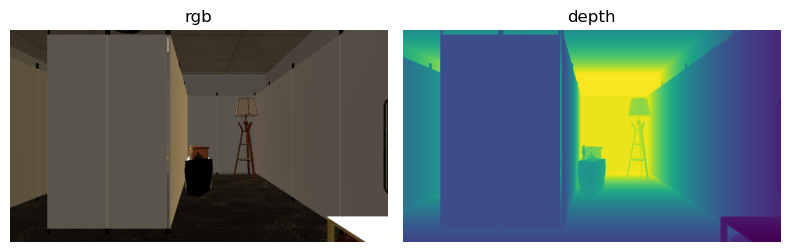

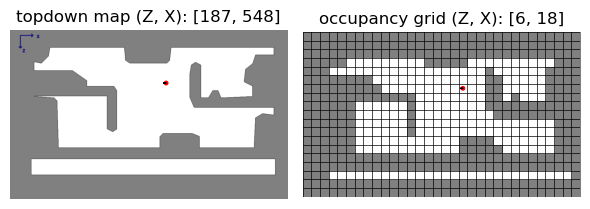

Action:  move_forward


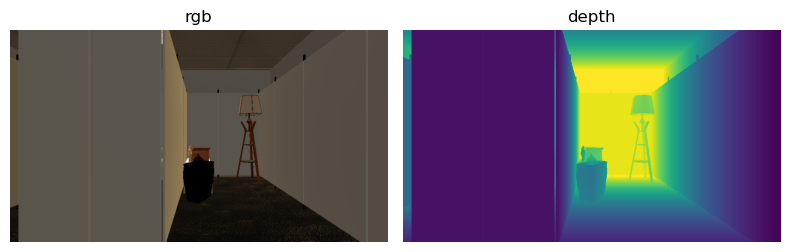

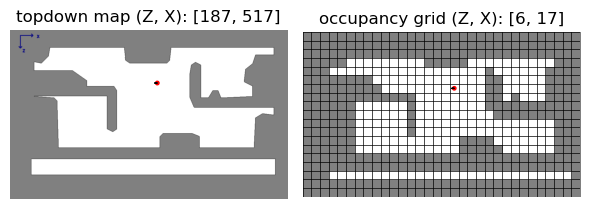

Action:  move_forward


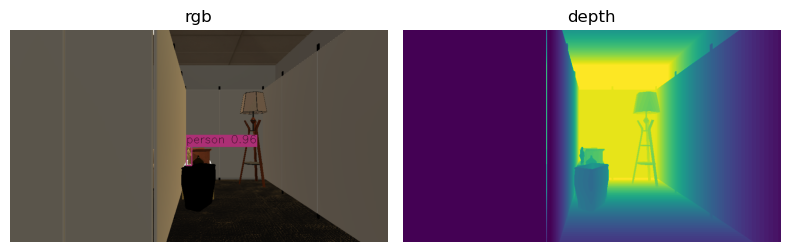

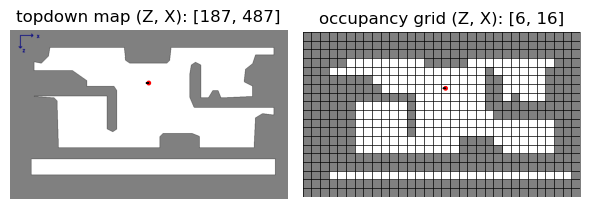

Action:  move_forward


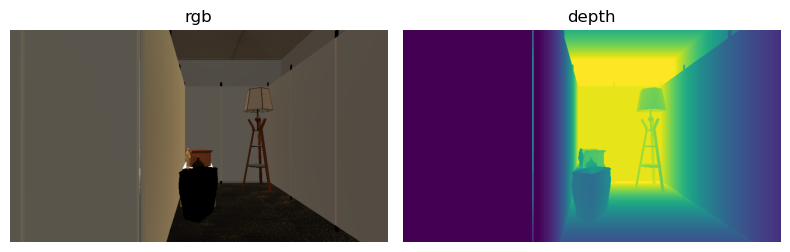

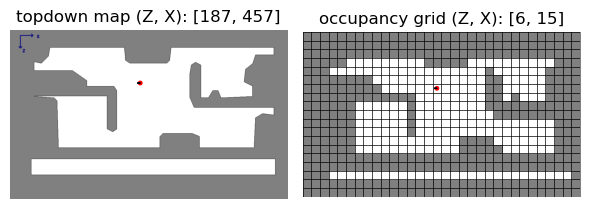

Action:  move_forward


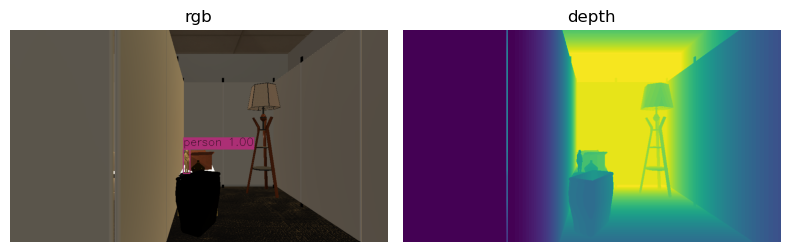

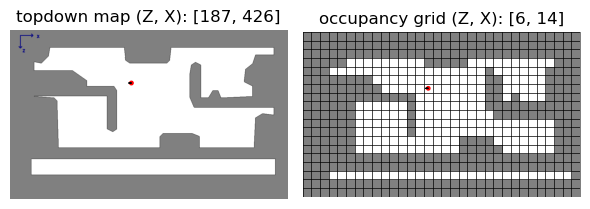

Action:  move_forward


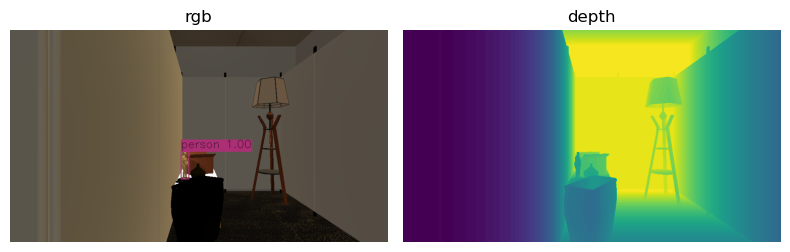

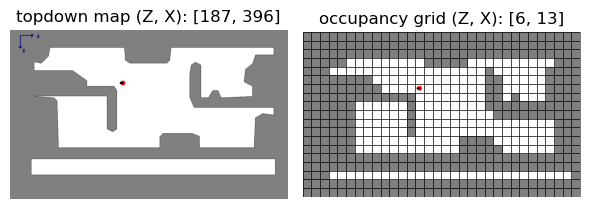

Action:  move_forward


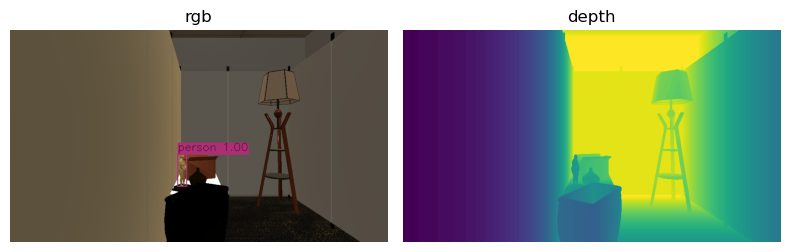

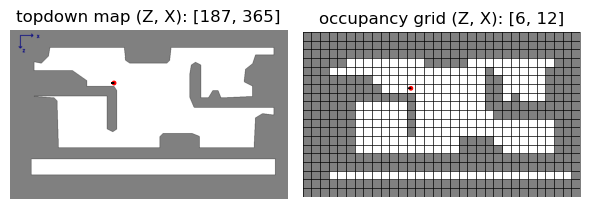

Action:  move_forward


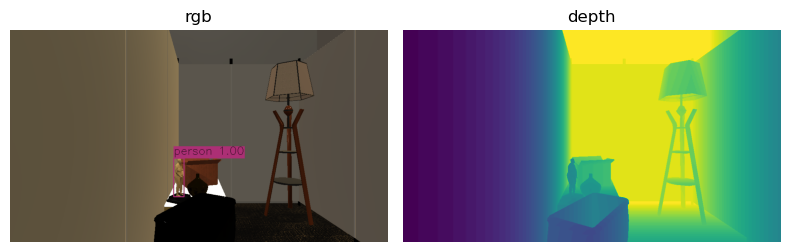

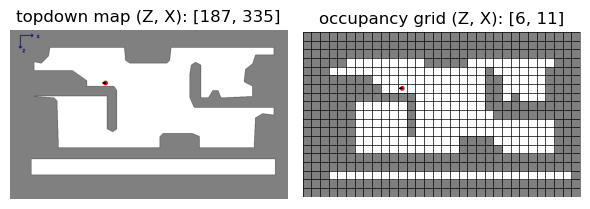

Action:  move_forward


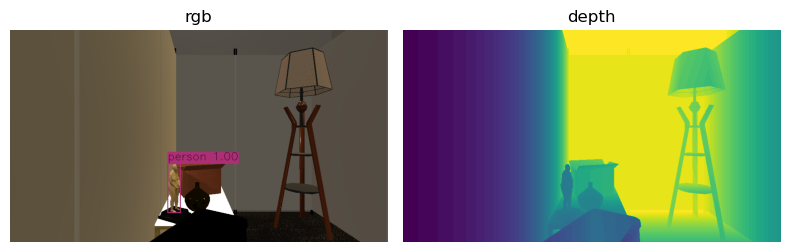

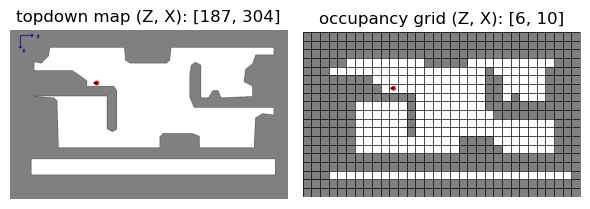

Taking observations at cluster center: [6, 10]
Action:  turn_right


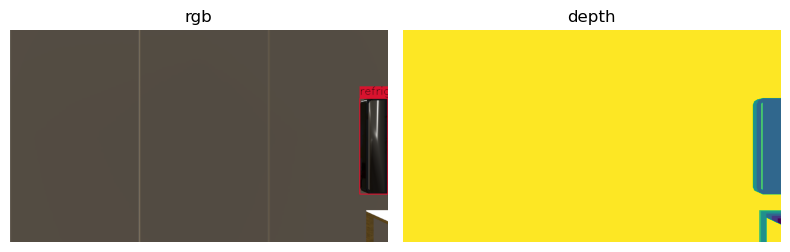

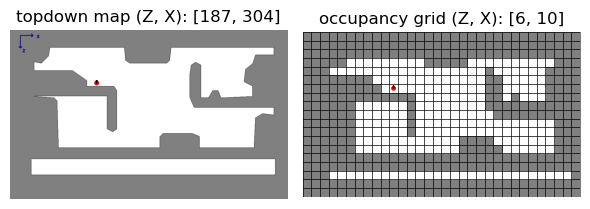

Action:  turn_right


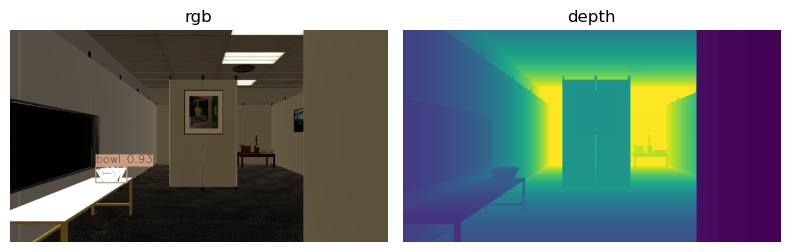

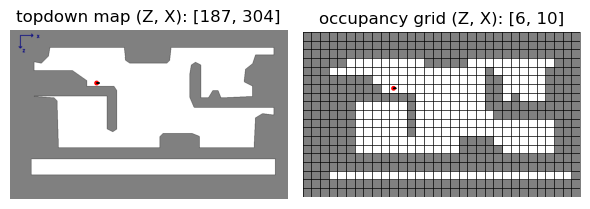

Action:  turn_right


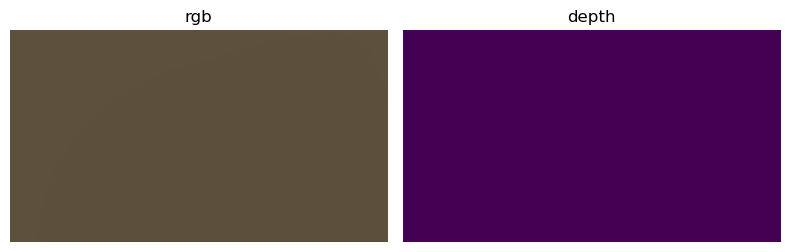

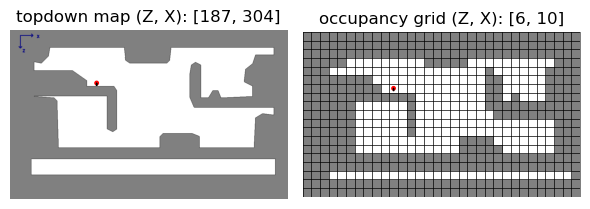

NEXT CLUSTER: [12, 11]
PATH: [[6, 11], [6, 12], [6, 13], [7, 13], [8, 13], [9, 13], [10, 13], [11, 13], [12, 13], [12, 12], [12, 11]]
Action:  move_left


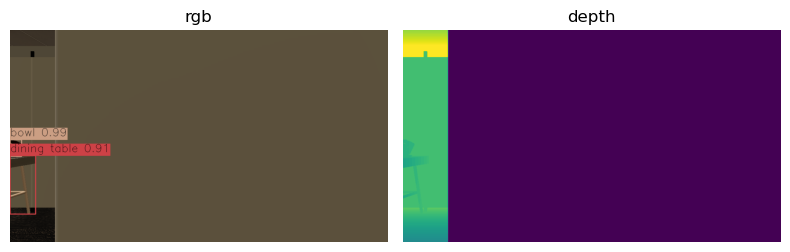

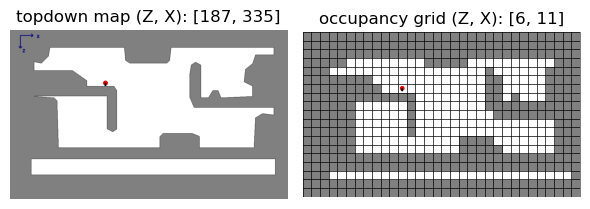

Action:  move_left


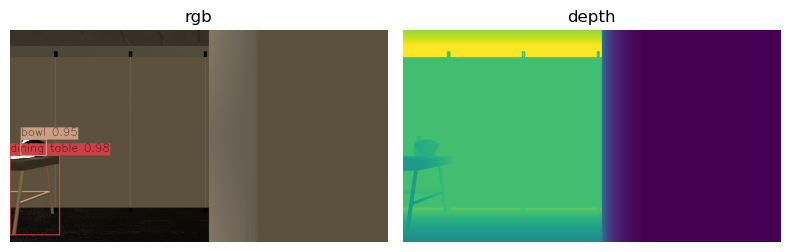

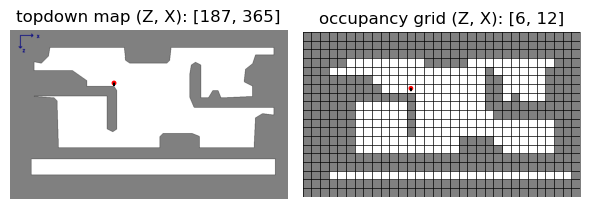

Action:  move_left


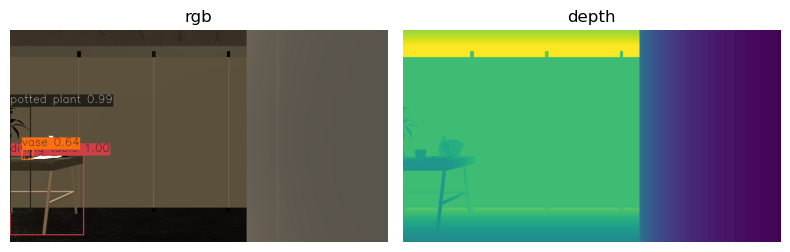

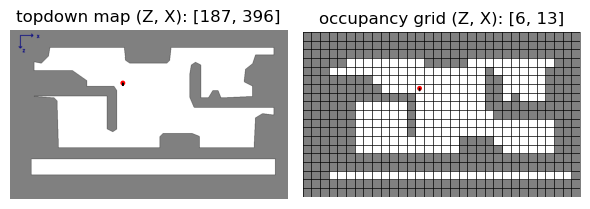

Action:  move_forward


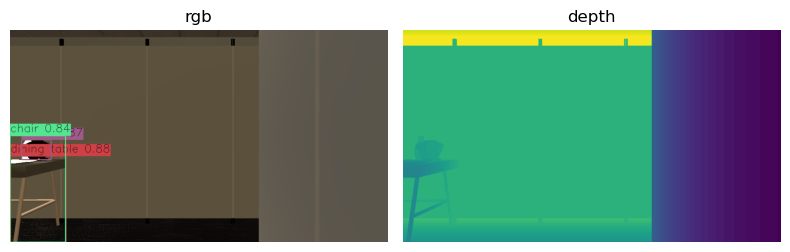

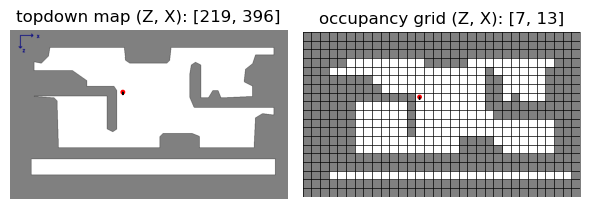

Action:  move_forward


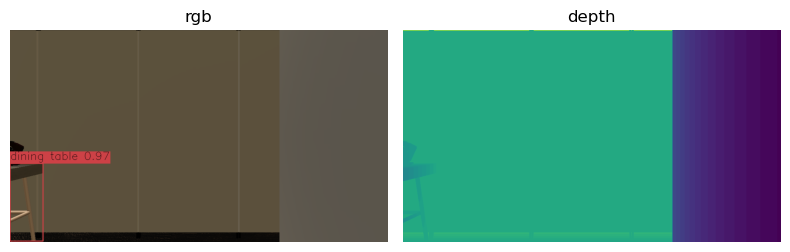

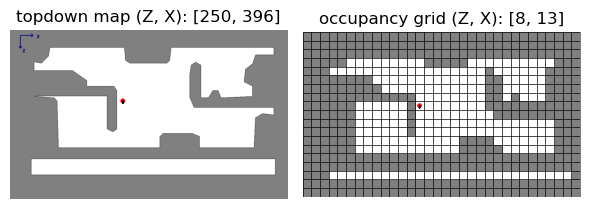

Action:  move_forward


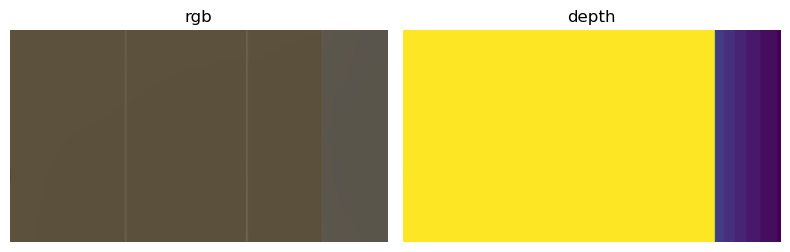

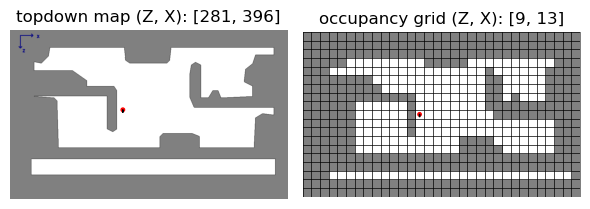

Action:  move_forward


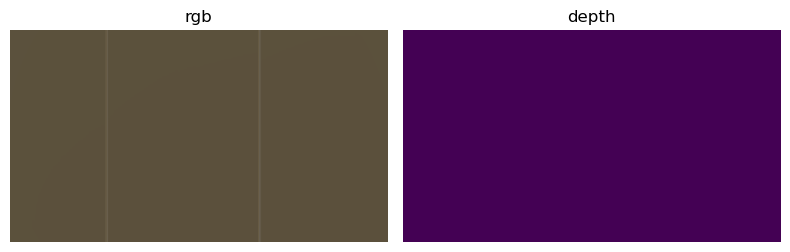

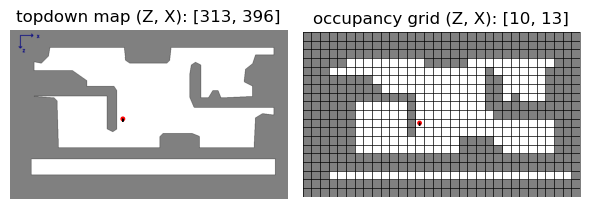

Action:  turn_right


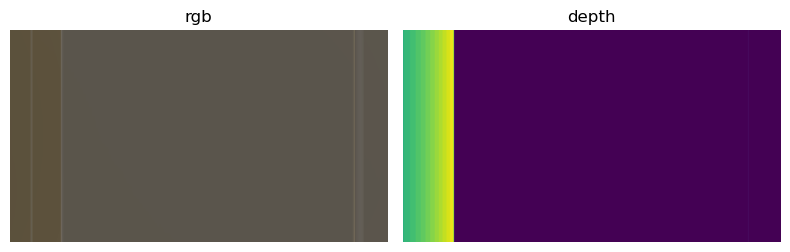

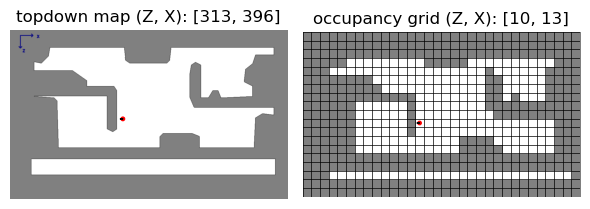

Action:  move_left


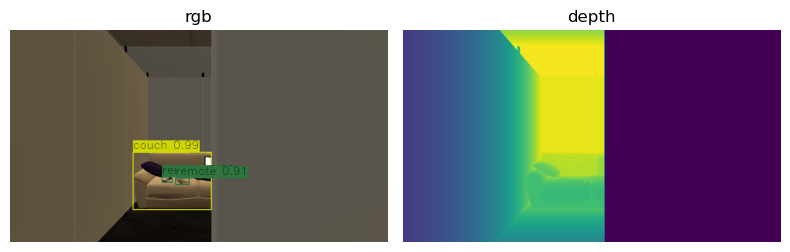

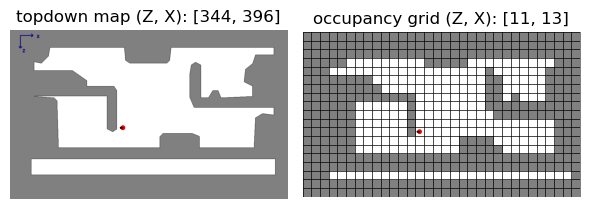

Action:  move_left


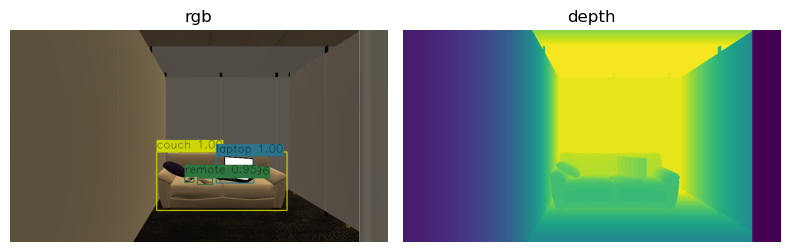

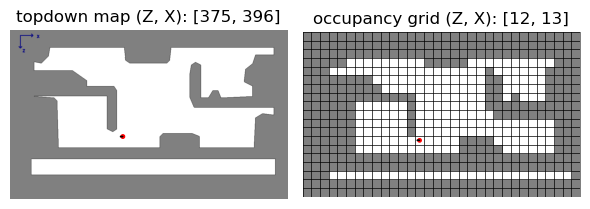

In [6]:
# Main simulation loop
while (num_clusters <= MAX_NUM_CLUSTER) and (num_actions < MAX_ITER) and (not OBJECT_FOUND):
    
    # Cluster free grid cells
    print("-------------------------------")
    print(f"Number of clusters: {num_clusters}")
    cluster_map = simtools.cluster_mapping(grid_occ_positions, num_clusters)
    grid_clusters = simtools.get_cluster_centers(cluster_map, num_clusters)
    simtools.display_topdown_maps_with_clusters(topdown_map, occ_grid_map, agent_positions_tpl, agent_radius_tpl, agent_yaw, cluster_map, num_clusters, grid_clusters)
    print("-------------------------------")

    # Go through each cluster center
    while (grid_clusters) and (num_actions < MAX_ITER) and (not OBJECT_FOUND):

        # Select closest cluster center to move to and the path to it
        grid_cluster, path = simtools.get_closest_cluster_path(grid_position, grid_clusters, grid_occ_positions)
        print(f"NEXT CLUSTER: {grid_cluster}")
        print(f"PATH: {path}")

        # 1 - Move along the path to the cluster center
        while (path) and (num_actions < MAX_ITER) and (not OBJECT_FOUND):
            
            # Compute optimal rotation to face the end of the path and action to achieve it
            facing_yaw = simtools.compute_facing_rotation(grid_position, path[-1])
            action = simtools.compute_rotation_action(agent_yaw, facing_yaw)

            # Perform a rotation action if needed
            if action is not None:
                grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
                agent_quart = myutils.yaw_to_quaternion(agent_yaw)
                agent_state.rotation = agent_quart
                agent.set_state(agent_state)

                # Update metrics
                num_actions += 1
                
                # Get observations
                observations = sim.get_sensor_observations(0)
                rgb = observations["color_sensor"]
                depth = observations["depth_sensor"]

                # YOLO Prediction
                results = yolo_model.predict(source=rgb[:, :, :3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
                xyxy, conf, cls, prob_vectors, names, num_detections = simtools.parse_detection_results(results)
                simtools.merge_rgb_yolo_outputs(rgb, xyxy, cls, conf, names)
                OBJECT_FOUND, bbox = simtools.was_object_found(TARGET_OBJECT_ID, cls, conf, xyxy, CONFIDENCE_THRESHOLD)

                # Display the simulation state
                if num_actions % DISPLAY_STEP == 0:
                    print("Action: ", action)
                    simtools.display_sim_observations(rgb, depth)
                    simtools.display_topdown_maps(topdown_map, occ_grid_map, agent_positions_tpl, agent_radius_tpl, agent_yaw)

            # Check if object was found
            if OBJECT_FOUND: break

            # Compute the move action to move to next path cell and perform it
            action = simtools.compute_move_action_relative(grid_position, path[0], agent_yaw)
            grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
            idx = grid_occ_positions.index(grid_position)
            map_position = map_occ_positions[idx]
            wrld_position = real_wrld_positions[idx]
            agent_positions_tpl = (map_position, grid_position)
            agent_state.position = wrld_position
            agent.set_state(agent_state)

            # Update metrics
            travelled_distance += CELL_SIDE
            num_actions += 1

            # Get observations
            observations = sim.get_sensor_observations(0)
            rgb = observations["color_sensor"]
            depth = observations["depth_sensor"]

            # YOLO Prediction
            results = yolo_model.predict(source=rgb[:, :, :3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
            xyxy, conf, cls, prob_vectors, names, num_detections = simtools.parse_detection_results(results)
            simtools.merge_rgb_yolo_outputs(rgb, xyxy, cls, conf, names)
            OBJECT_FOUND, bbox = simtools.was_object_found(TARGET_OBJECT_ID, cls, conf, xyxy, CONFIDENCE_THRESHOLD)

            # Display the simulation state
            if num_actions % DISPLAY_STEP == 0:
                print("Action: ", action)
                simtools.display_sim_observations(rgb, depth)
                simtools.display_topdown_maps(topdown_map, occ_grid_map, agent_positions_tpl, agent_radius_tpl, agent_yaw)

            # Remove the path cell from the path
            path.pop(0)

        # If the target object is found, break
        if OBJECT_FOUND: break

        # 2 - Take observations at the cluster center
        print(f"Taking observations at cluster center: {grid_cluster}")
        for i in range(3):

            # Perform the action
            grid_position, agent_yaw = simtools.perform_action('turn_right', grid_position, agent_yaw)
            agent_quart = myutils.yaw_to_quaternion(agent_yaw)
            agent_state.rotation = agent_quart
            agent.set_state(agent_state)

            # Update metrics
            num_actions += 1

            # Get observations
            observations = sim.get_sensor_observations(0)
            rgb = observations["color_sensor"]
            depth = observations["depth_sensor"]

            # YOLO Prediction
            results = yolo_model.predict(source=rgb[:, :, :3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
            xyxy, conf, cls, prob_vectors, names, num_detections = simtools.parse_detection_results(results)
            simtools.merge_rgb_yolo_outputs(rgb, xyxy, cls, conf, names)
            OBJECT_FOUND, bbox = simtools.was_object_found(TARGET_OBJECT_ID, cls, conf, xyxy, CONFIDENCE_THRESHOLD)
            
            # Display the simulation state
            if num_actions % DISPLAY_STEP == 0:
                print("Action: ", 'turn_right')
                simtools.display_sim_observations(rgb, depth)
                simtools.display_topdown_maps(topdown_map, occ_grid_map, agent_positions_tpl, agent_radius_tpl, agent_yaw)

            # If the target object is found, break
            if OBJECT_FOUND: break 

        # Remove the grid cluster center from the list
        grid_clusters.remove(grid_cluster)

    # Double the number of clusters
    num_clusters *= 2


Target object <laptop> found after 35 actions!
Found location: [    -9.3942     0.52333     -2.1457]
Real location: [-9.241811752319336, 0.35663527250289917, -2.1109025478363037]


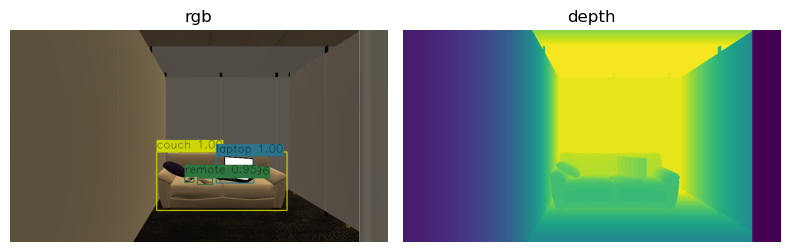

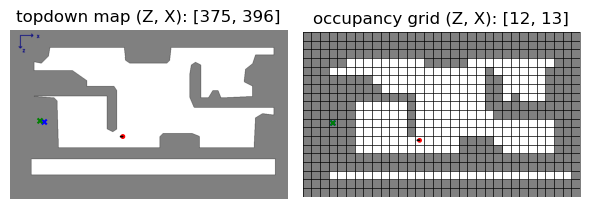

Number of actions: 35
Travelled distance: 7.80 m
Computed localization error: 0.156 m


In [7]:
# If object is found, compute its real world position
if OBJECT_FOUND:
    # Get the bounding box of the target object
    x1, y1, x2, y2 = bbox
    center_x = int((x1 + x2) / 2)
    center_y = int((y1 + y2) / 2)
    depth_value = depth[center_y, center_x]

    # Compute the real world position of the target object
    target_object_position = simtools.compute_real_world_position(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, cam_intrcs)

    # Compute the closeness to the target location
    closeness = simtools.compute_closeness(target_object_position, REAL_TARGET_LOCATION)

    # Convert to 2D coordinates
    target_map_position, target_grid_position = simtools.get_2d_coords(target_object_position, topdown_resolution, occ_grid_resolution, sim.pathfinder)
    target_real_map_position, target_real_grid_position = simtools.get_2d_coords(REAL_TARGET_LOCATION, topdown_resolution, occ_grid_resolution, sim.pathfinder)
    target_2d_coords = (target_map_position, target_grid_position)
    target_real_2d_coords = (target_real_map_position, target_real_grid_position)
    target_coords_tpl = (target_real_2d_coords, target_2d_coords)

    # Show info
    print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions!")
    print(f"Found location: {target_object_position}")
    print(f"Real location: {REAL_TARGET_LOCATION}")
    simtools.display_sim_observations(rgb, depth)
    simtools.display_topdown_maps_with_target(topdown_map, occ_grid_map, agent_positions_tpl, agent_radius_tpl, agent_yaw, target_coords_tpl)
else:
    print(f"\nTarget object <{TARGET_OBJECT}> not found after {MAX_ITER} actions!")
    print(f"Real location: {REAL_TARGET_LOCATION}")

# Display simulation metrics
print(f"Number of actions: {num_actions}")
print(f"Travelled distance: {travelled_distance:.2f} m")
print(f"Computed localization error: {closeness:.3f} m")